In [5]:
# from spod_scalar_maskedv1 import spod_scalar_masked, plot_spod_spectrum, plot_modes_grid
from spod_scalar_maskedv2 import (
    spod_scalar_masked, plot_spod_spectrum, plot_modes_grid, pick_peak_index
)
import h5py, numpy as np, matplotlib.pyplot as plt

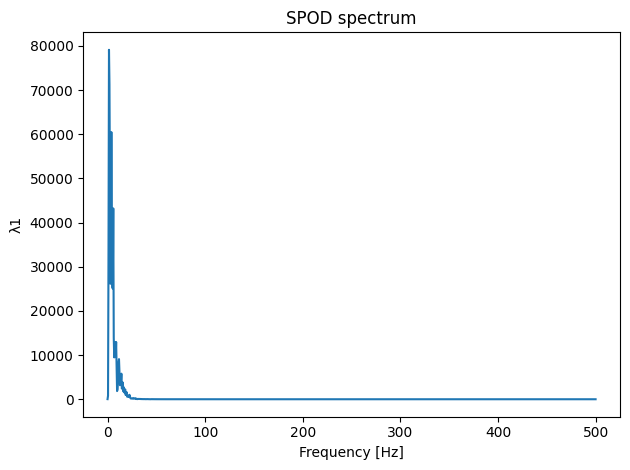

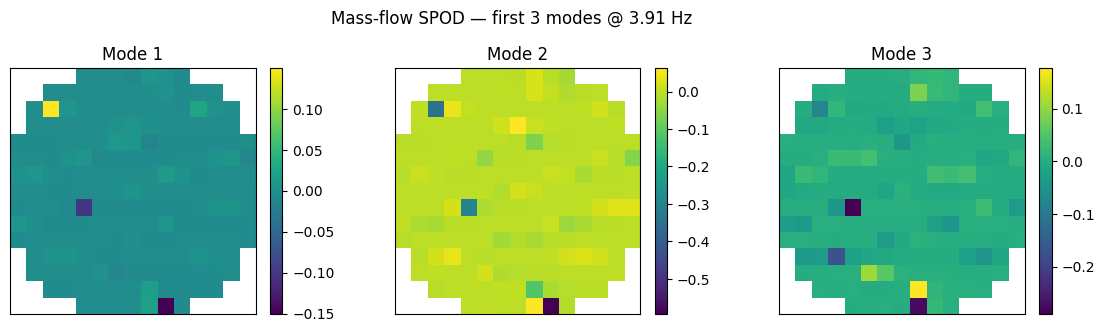

In [14]:
with h5py.File("hdf5MF/plane_09_lowest.h5","r") as f:
    data = f["/data"][...]
    time = f["/time"][...]

# mask from mean magnitude (or use your project mask)
mask = np.mean(np.abs(data), axis=0) > 1e-6*np.max(np.abs(data))

res = spod_scalar_masked(
    data, mask, time=time,
    nfft=2048, overlap=0.75, nmodes=3, window="hann",
    remove_domain_mean=True,      # kill global rank-1
    normalize="relative",         # flatten profile (try "zscore" too)
    highpass_hz=1.0              # or set e.g. 1.0 if low-freq residue remains
)

# Spectrum and modes at a non-DC peak
plt.figure(); plot_spod_spectrum(res["evals"], res["freqs"]); plt.tight_layout(); plt.show()
fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=2.0)   # ignore DC
fpk = res["freqs"][fi]
plot_modes_grid(res["modes"][fi], fpk, title_prefix="Mass-flow SPOD"); plt.show()

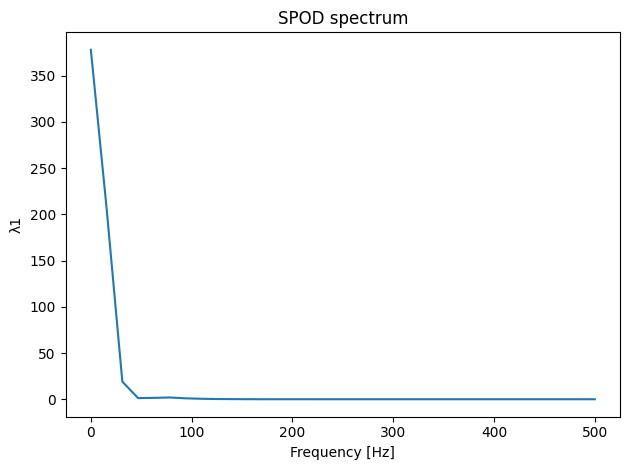

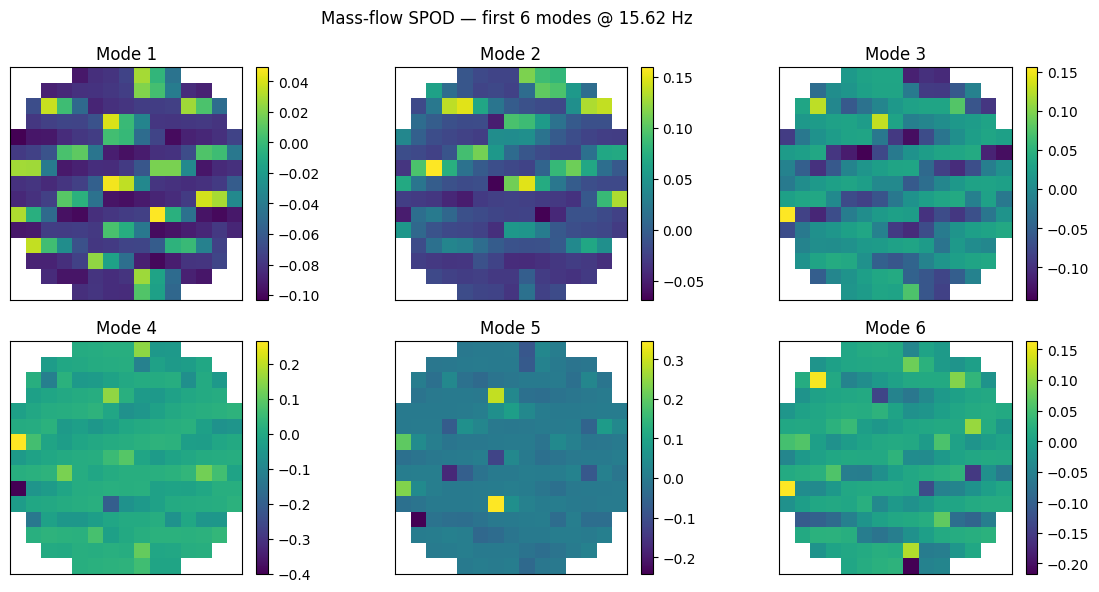

In [22]:
res = spod_scalar_masked(data, mask, time=time,
    nfft=64, overlap=0.90, window="hann",
    remove_domain_mean=True, normalize="zscore", highpass_hz=5.0, nmodes=6)

# Spectrum and modes at a non-DC peak
plt.figure(); plot_spod_spectrum(res["evals"], res["freqs"]); plt.tight_layout(); plt.show()
fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=2.0)   # ignore DC
fpk = res["freqs"][fi]
plot_modes_grid(res["modes"][fi], fpk, title_prefix="Mass-flow SPOD"); plt.show()

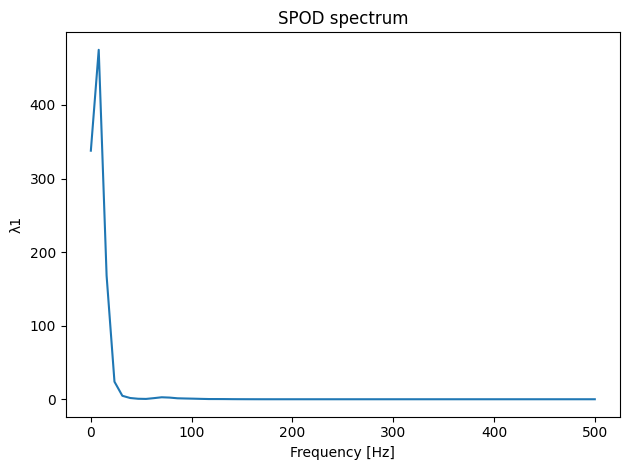

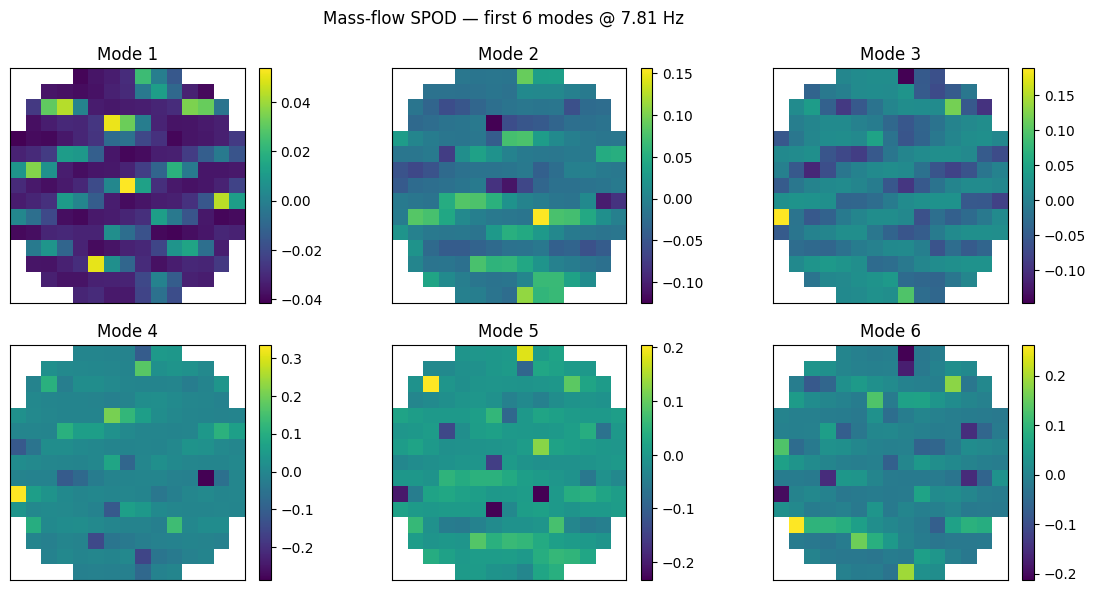

In [15]:
res = spod_scalar_masked(data, mask, time=time,
    nfft=128, overlap=0.90, window="hann",
    remove_domain_mean=True, normalize="zscore", highpass_hz=5.0, nmodes=6)

# Spectrum and modes at a non-DC peak
plt.figure(); plot_spod_spectrum(res["evals"], res["freqs"]); plt.tight_layout(); plt.show()
fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=2.0)   # ignore DC
fpk = res["freqs"][fi]
plot_modes_grid(res["modes"][fi], fpk, title_prefix="Mass-flow SPOD"); plt.show()

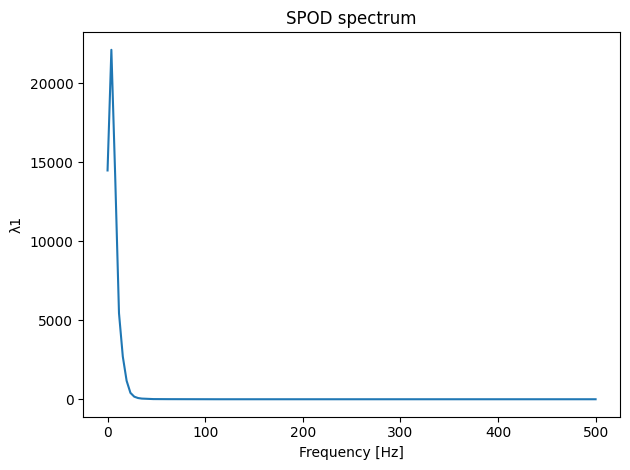

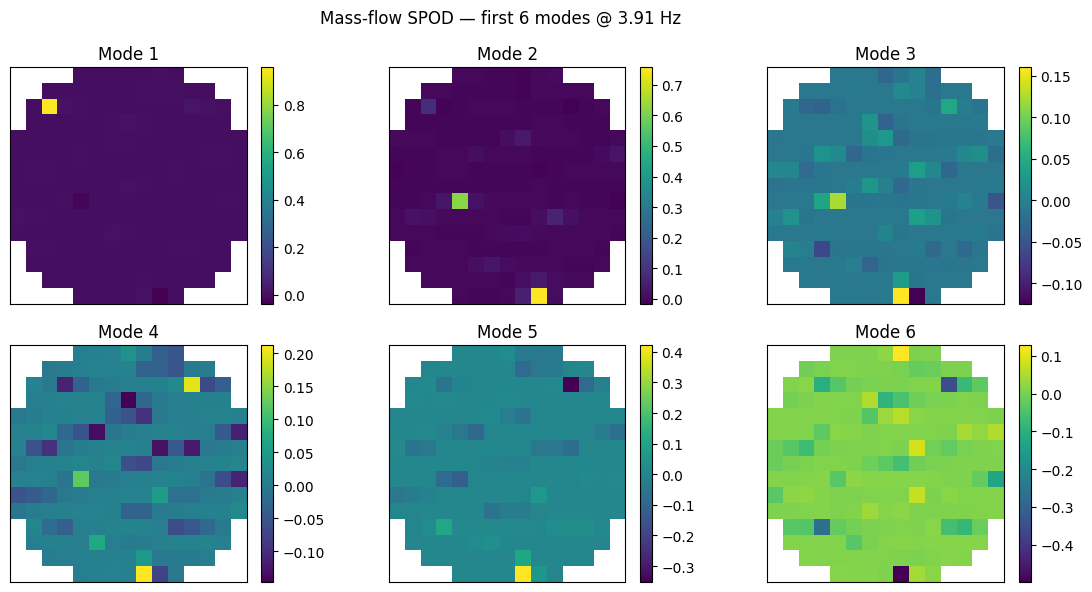

In [17]:
res = spod_scalar_masked(data, mask, time=time,
    nfft=256, overlap=0.75, window="hann",
    remove_domain_mean=True, normalize="relative", highpass_hz=2.0, nmodes=6)

# Spectrum and modes at a non-DC peak
plt.figure(); plot_spod_spectrum(res["evals"], res["freqs"]); plt.tight_layout(); plt.show()
fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=2.0)   # ignore DC
fpk = res["freqs"][fi]
plot_modes_grid(res["modes"][fi], fpk, title_prefix="Mass-flow SPOD"); plt.show()

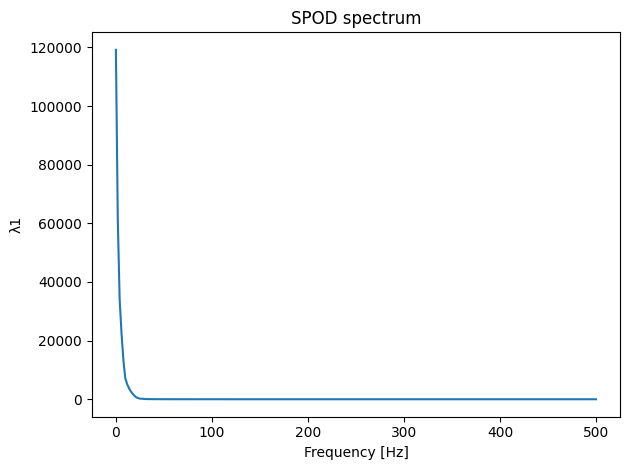

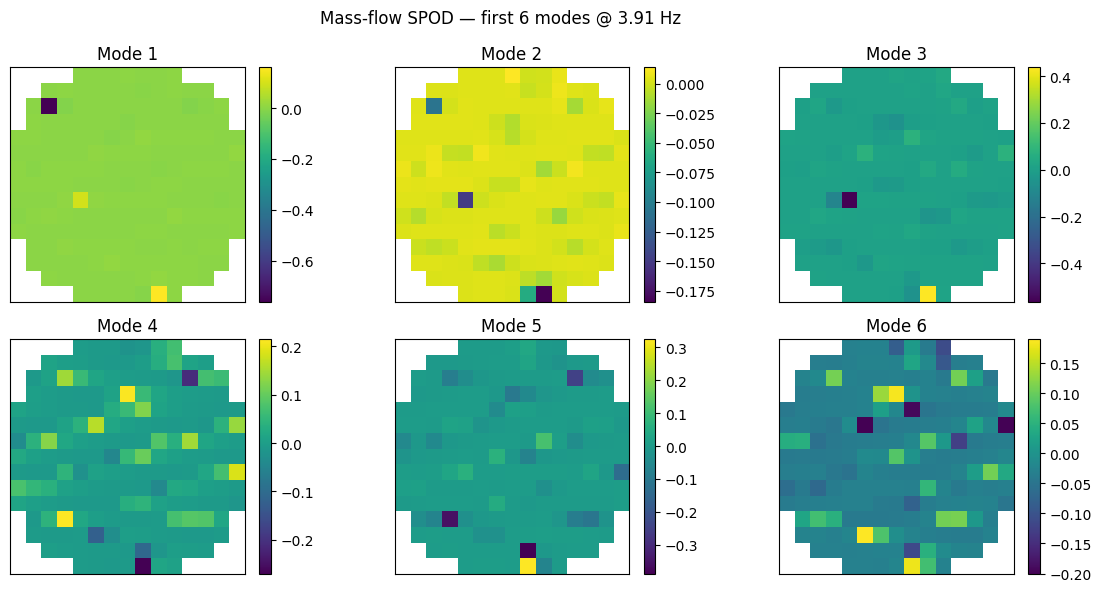

In [21]:
res = spod_scalar_masked(data, mask, time=time,
    nfft=512, overlap=0.75, window="hann",
    remove_domain_mean=True, normalize="relative", highpass_hz=2.0, nmodes=6)

# Spectrum and modes at a non-DC peak
plt.figure(); plot_spod_spectrum(res["evals"], res["freqs"]); plt.tight_layout(); plt.show()
fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=2.0)   # ignore DC
fpk = res["freqs"][fi]
plot_modes_grid(res["modes"][fi], fpk, title_prefix="Mass-flow SPOD"); plt.show()

# Parameter Sweep

A: nfft=128, 90% ovlp, zscore, HP 5 Hz: Tw=0.128s, Δf=7.812Hz, hop=12 samp, K=407 blocks
B: nfft=256, 75% ovlp, relative, HP 2 Hz: Tw=0.256s, Δf=3.906Hz, hop=64 samp, K=75 blocks
C: nfft=512, 75% ovlp, relative, HP 2 Hz: Tw=0.512s, Δf=1.953Hz, hop=128 samp, K=36 blocks


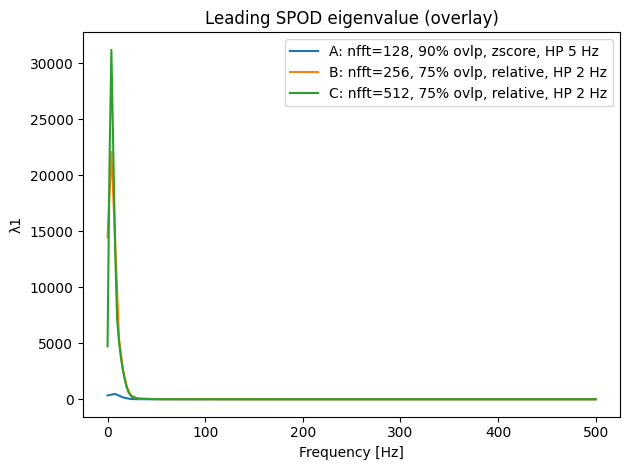

A: nfft=128, 90% ovlp, zscore, HP 5 Hz -> peak ≥ 2.0 Hz at 7.81 Hz


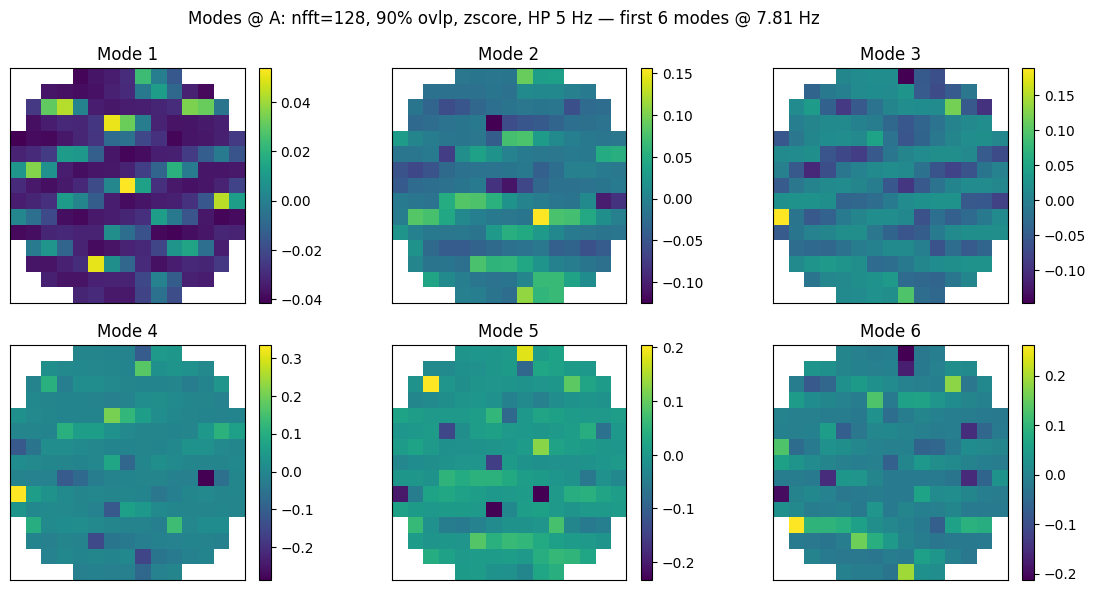

B: nfft=256, 75% ovlp, relative, HP 2 Hz -> peak ≥ 2.0 Hz at 3.91 Hz


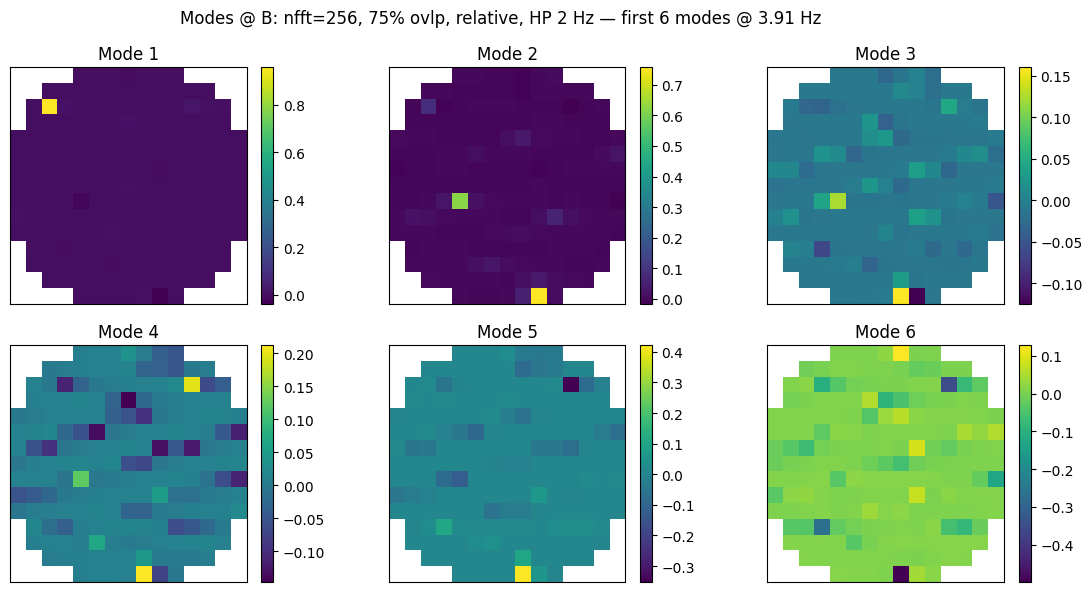

C: nfft=512, 75% ovlp, relative, HP 2 Hz -> peak ≥ 2.0 Hz at 3.91 Hz


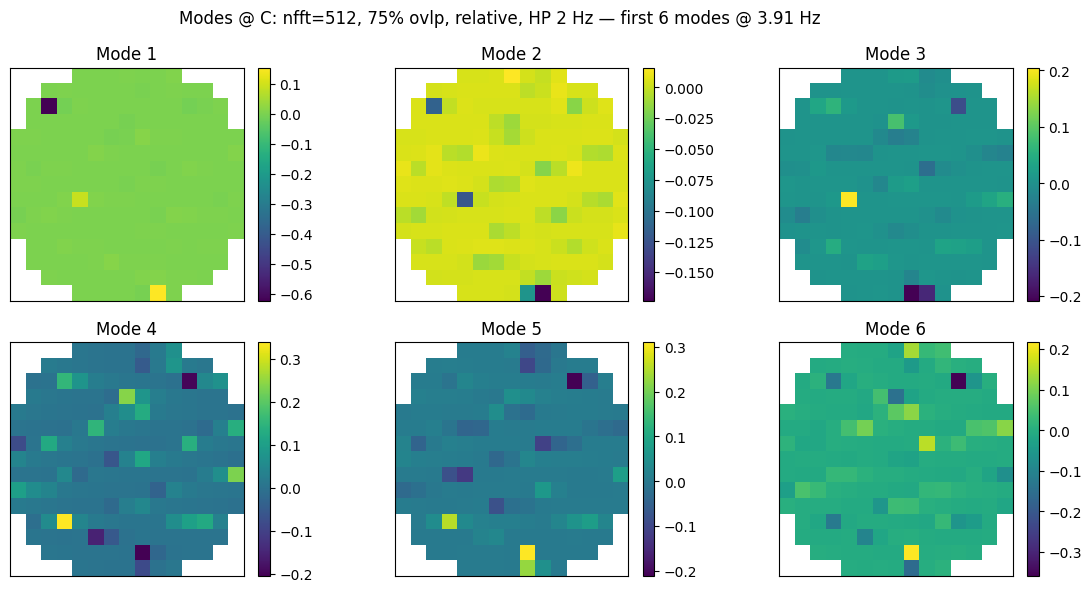

In [23]:
from spod_scalar_maskedv2 import (
    spod_scalar_masked, plot_spod_spectrum, plot_modes_grid, pick_peak_index
)
import h5py, numpy as np, matplotlib.pyplot as plt

# --- Load data/time and a mask (use your project mask if available) ---
with h5py.File("hdf5MF/plane_09_lowest.h5","r") as f:
    data = f["/data"][...]            # (T,H,W)
    time = f["/time"][...]            # (T,)
mask = np.mean(np.abs(data), axis=0) > 1e-6*np.max(np.abs(data))

# --- Three configs tuned for fast/bursty signals ---
configs = [
    dict(label="A: nfft=128, 90% ovlp, zscore, HP 5 Hz",
         nfft=128, overlap=0.90, normalize="zscore", highpass_hz=5.0),
    dict(label="B: nfft=256, 75% ovlp, relative, HP 2 Hz",
         nfft=256, overlap=0.75, normalize="relative", highpass_hz=2.0),
    dict(label="C: nfft=512, 75% ovlp, relative, HP 2 Hz",
         nfft=512, overlap=0.75, normalize="relative", highpass_hz=2.0),
]
# Common knobs
COMMON = dict(remove_domain_mean=True, window="hann", nmodes=6)

# --- Run SPOD for each config ---
results = []
for cfg in configs:
    res = spod_scalar_masked(
        data, mask, time=time,
        nfft=cfg["nfft"], overlap=cfg["overlap"],
        normalize=cfg["normalize"], highpass_hz=cfg["highpass_hz"],
        **COMMON
    )
    results.append((cfg, res))
    # Print window metrics
    dt = res["dt"]; Tw = cfg["nfft"]*dt; df = 1.0/Tw; hop = int(cfg["nfft"]*(1-cfg["overlap"]))
    print(f"{cfg['label']}: Tw={Tw:.3f}s, Δf={df:.3f}Hz, hop={hop} samp, K={res['K']} blocks")

# --- Overlay leading SPOD spectra ---
plt.figure()
ax = plt.gca()
for cfg, res in results:
    ax.plot(res["freqs"], res["evals"][:,0], label=cfg["label"])
ax.set_xlabel("Frequency [Hz]"); ax.set_ylabel("λ1"); ax.set_title("Leading SPOD eigenvalue (overlay)")
ax.legend(); plt.tight_layout(); plt.show()

# --- Plot 2×3 mode grids at each setting’s non-DC peak ---
fmin_hz = 2.0  # ignore DC when picking peaks; adjust as needed
for cfg, res in results:
    fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=fmin_hz, which=0)
    fpk = float(res["freqs"][fi])
    print(f"{cfg['label']} -> peak ≥ {fmin_hz} Hz at {fpk:.2f} Hz")
    plot_modes_grid(res["modes"][fi], fpk, title_prefix=f"Modes @ {cfg['label']}")
    plt.show()

# Comprehensive Sweep

Running: nfft=128, ovlp=50%, relative, HP=0  (K=77)
Running: nfft=128, ovlp=50%, relative, HP=2.0  (K=77)
Running: nfft=128, ovlp=50%, relative, HP=5.0  (K=77)
Running: nfft=128, ovlp=50%, zscore, HP=0  (K=77)
Running: nfft=128, ovlp=50%, zscore, HP=2.0  (K=77)
Running: nfft=128, ovlp=50%, zscore, HP=5.0  (K=77)
Running: nfft=128, ovlp=75%, relative, HP=0  (K=153)
Running: nfft=128, ovlp=75%, relative, HP=2.0  (K=153)
Running: nfft=128, ovlp=75%, relative, HP=5.0  (K=153)
Running: nfft=128, ovlp=75%, zscore, HP=0  (K=153)
Running: nfft=128, ovlp=75%, zscore, HP=2.0  (K=153)
Running: nfft=128, ovlp=75%, zscore, HP=5.0  (K=153)
Running: nfft=128, ovlp=90%, relative, HP=0  (K=407)
Running: nfft=128, ovlp=90%, relative, HP=2.0  (K=407)
Running: nfft=128, ovlp=90%, relative, HP=5.0  (K=407)
Running: nfft=128, ovlp=90%, zscore, HP=0  (K=407)
Running: nfft=128, ovlp=90%, zscore, HP=2.0  (K=407)
Running: nfft=128, ovlp=90%, zscore, HP=5.0  (K=407)
Running: nfft=256, ovlp=50%, relative, HP=0  (

,label,nfft,overlap,normalize,highpass_hz,K,hop,Tw,df,fpk,lam1_pk,lam2_lam1
73,"nfft=2048, ovlp=90%, relative, HP=2.0",2048,0.90,relative,2.0,15,204,2.048,0.488281,3.906250,60213.430840,0.041412
72,"nfft=2048, ovlp=90%, relative, HP=0",2048,0.90,relative,NaN,15,204,2.048,0.488281,3.906250,60197.345757,0.041347
74,"nfft=2048, ovlp=90%, relative, HP=5.0",2048,0.90,relative,5.0,15,204,2.048,0.488281,5.859375,44879.249642,0.084216
54,"nfft=1024, ovlp=50%, relative, HP=0",1024,0.50,relative,NaN,8,512,1.024,0.976562,3.906250,41718.880854,0.157443
55,"nfft=1024, ovlp=50%, relative, HP=2.0",1024,0.50,relative,2.0,8,512,1.024,0.976562,3.906250,41679.211499,0.166022
61,"nfft=1024, ovlp=75%, relative, HP=2.0",1024,0.75,relative,2.0,16,256,1.024,0.976562,3.906250,38507.689000,0.162194
60,"nfft=1024, ovlp=75%, relative, HP=0",1024,0.75,relative,NaN,16,256,1.024,0.976562,3.906250,38378.535563,0.160804
67,"nfft=1024, ovlp=90%, relative, HP=2.0",1024,0.90,relative,2.0,39,102,1.024,0.976562,3.906250,38365.135048,0.149939
66,"nfft=1024, ovlp=90%, relative, HP=0",1024,0.90,relative,NaN,39,102,1.024,0.976562,3.906250,38351.935732,0.149159
30,"nfft=256, ovlp=90%, relative, HP=0",256,0.90,relative,NaN,190,25,0.256,3.906250,3.906250,34893.512406,0.783751


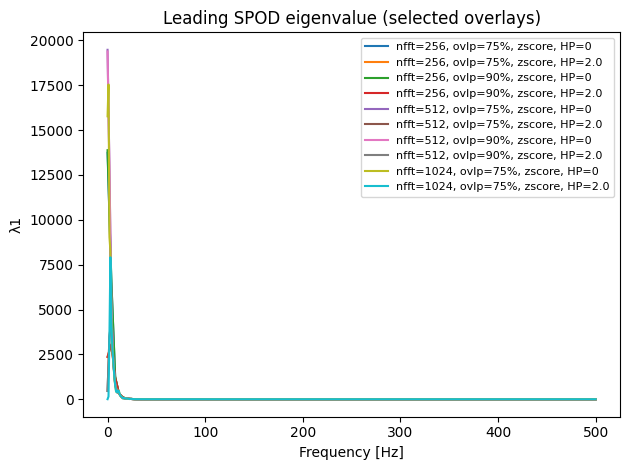


Top 1: nfft=2048, ovlp=90%, relative, HP=2.0 -> K=15, Tw=2.048s, Δf=0.488Hz, fpk=3.91Hz


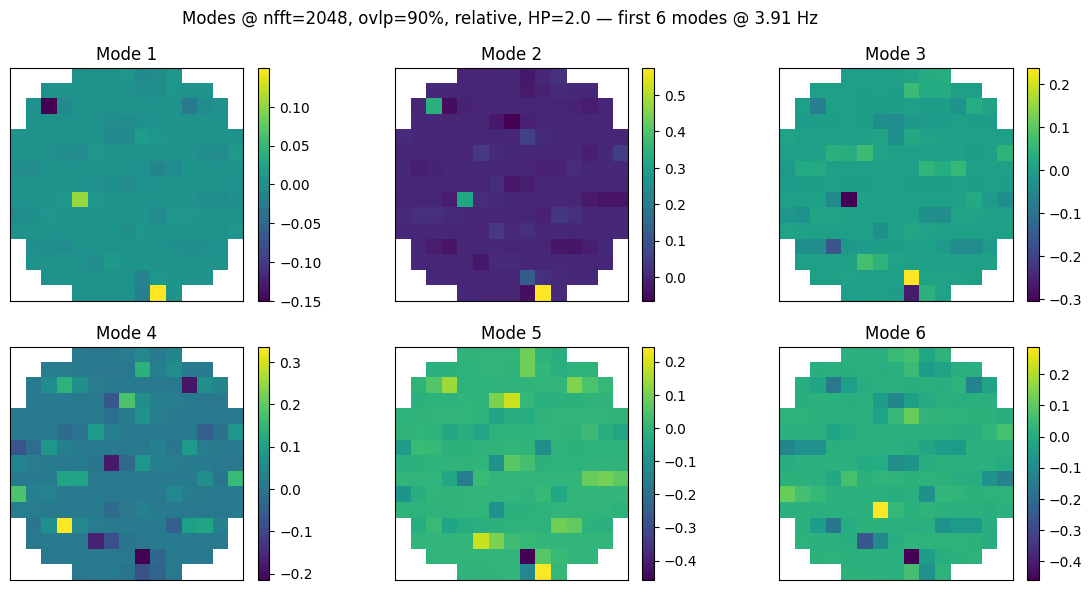


Top 2: nfft=2048, ovlp=90%, relative, HP=0 -> K=15, Tw=2.048s, Δf=0.488Hz, fpk=3.91Hz


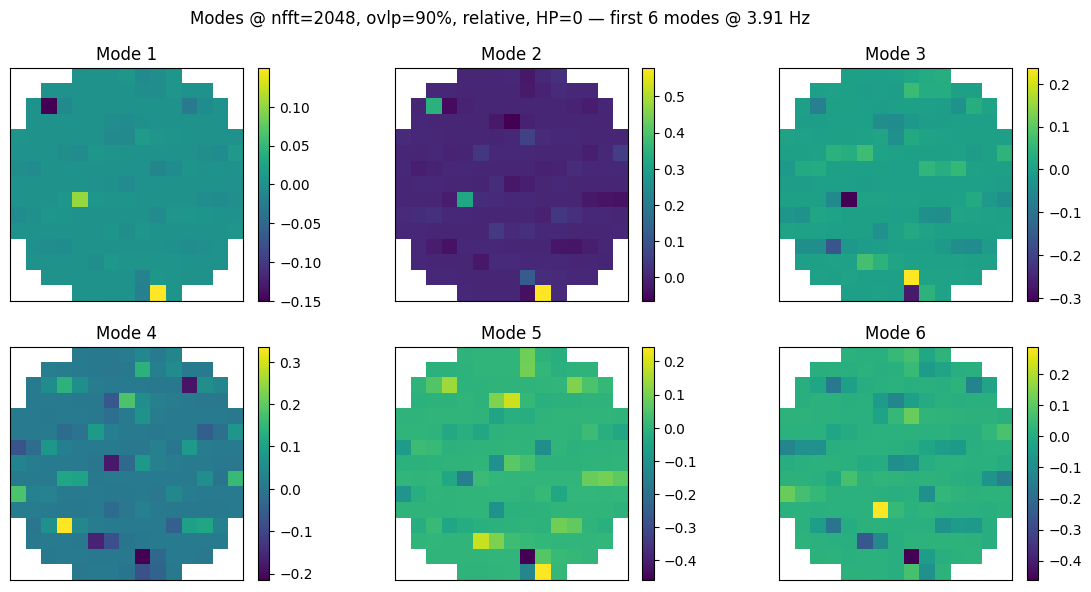


Top 3: nfft=2048, ovlp=90%, relative, HP=5.0 -> K=15, Tw=2.048s, Δf=0.488Hz, fpk=5.86Hz


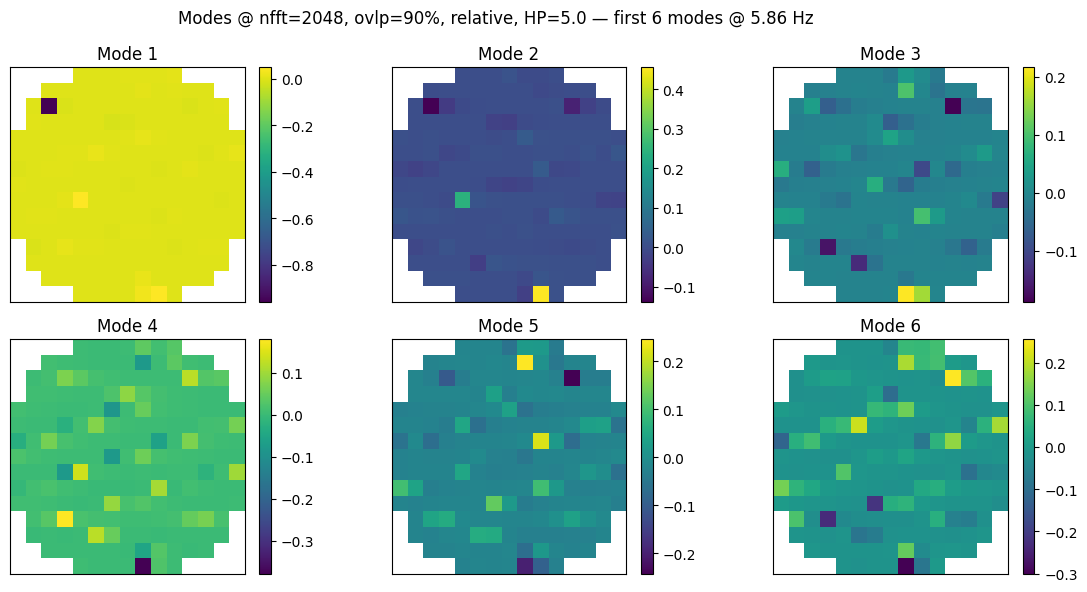

In [24]:
from spod_scalar_maskedv2 import (
    spod_scalar_masked, plot_spod_spectrum, plot_modes_grid, pick_peak_index
)
import h5py, numpy as np, matplotlib.pyplot as plt
import itertools
import pandas as pd

# --- Load data + build a mask (replace with your project mask if you have one) ---
with h5py.File("hdf5MF/plane_09_lowest.h5","r") as f:
    data = f["/data"][...]            # (T,H,W)
    time = f["/time"][...]
mask = np.mean(np.abs(data), axis=0) > 1e-6*np.max(np.abs(data))

T = data.shape[0]
dt = np.median(np.diff(time))
fs = 1.0/dt

# --- Parameter grid ---
nfft_list      = [128, 256, 512, 1024, 2048]
overlap_list   = [0.50, 0.75, 0.90]
normalize_list = ["relative", "zscore"]
highpass_list  = [None, 2.0, 5.0]

COMMON = dict(remove_domain_mean=True, window="hann", nmodes=6)

def hop(nfft, ovlp): return int(nfft*(1.0-ovlp))

# For ranking: peak search should ignore DC and be >= any highpass cutoff
def fmin_for_cfg(hp): return max(2.0, hp if hp is not None else 0.0)

results = []
spectra_to_overlay = []

for nfft, ovlp, norm, hp in itertools.product(nfft_list, overlap_list, normalize_list, highpass_list):
    if nfft > T: 
        continue
    h = hop(nfft, ovlp)
    if h <= 0: 
        continue
    K = 1 + (T - nfft)//h
    if K < 8:          # skip unstable estimates
        continue

    cfg = dict(nfft=nfft, overlap=ovlp, normalize=norm, highpass_hz=hp)
    label = f"nfft={nfft}, ovlp={int(ovlp*100)}%, {norm}, HP={hp if hp is not None else 0}"
    print(f"Running: {label}  (K={K})")

    res = spod_scalar_masked(
        data, mask, time=time,
        nfft=nfft, overlap=ovlp, normalize=norm, highpass_hz=hp, **COMMON
    )

    freqs, evals = res["freqs"], res["evals"]
    fmin_hz = fmin_for_cfg(hp)
    fi = pick_peak_index(evals, freqs, fmin_hz=fmin_hz, which=0)
    fpk = float(freqs[fi])
    lam1 = float(evals[fi, 0])
    lam2 = float(evals[fi, 1]) if evals.shape[1] > 1 else 0.0
    ratio21 = lam2/lam1 if lam1 > 0 else 0.0

    Tw = nfft*dt
    df = 1.0/Tw

    results.append(dict(
        label=label, nfft=nfft, overlap=ovlp, normalize=norm, highpass_hz=hp,
        K=res["K"], hop=h, Tw=Tw, df=df, fpk=fpk, lam1_pk=lam1, lam2_lam1=ratio21
    ))

    # keep spectra for overlay (only a subset to avoid clutter)
    if (nfft in (256, 512, 1024, 2048)) and (ovlp in (0.75, 0.90)) and norm=="zscore" and (hp in (None, 2.0)):
        spectra_to_overlay.append((label, freqs, evals[:,0]))

# --- Summary table (top by non-DC λ1, then by λ2/λ1 indicating multi-rank) ---
df = pd.DataFrame(results).sort_values(["lam1_pk", "lam2_lam1"], ascending=[False, False])
print("Top configurations by non-DC peak λ1 (then λ2/λ1):")
display(df.head(10))

# --- Overlay a few leading spectra to compare shapes ---
plt.figure()
for label, fz, l1 in spectra_to_overlay[:10]:
    plt.plot(fz, l1, label=label)
plt.xlabel("Frequency [Hz]"); plt.ylabel("λ1"); plt.title("Leading SPOD eigenvalue (selected overlays)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot modes for the top 3 configurations ---
topN = 3
for i in range(min(topN, len(df))):
    row = df.iloc[i]
    print(f"\nTop {i+1}: {row['label']} -> K={int(row['K'])}, Tw={row['Tw']:.3f}s, Δf={row['df']:.3f}Hz, fpk={row['fpk']:.2f}Hz")
    res = spod_scalar_masked(
        data, mask, time=time,
        nfft=int(row["nfft"]), overlap=float(row["overlap"]),
        normalize=row["normalize"], highpass_hz=(None if np.isnan(row['highpass_hz']) else row["highpass_hz"]),
        **COMMON
    )
    fi = pick_peak_index(res["evals"], res["freqs"], fmin_hz=fmin_for_cfg(row["highpass_hz"]), which=0)
    plot_modes_grid(res["modes"][fi], res["freqs"][fi], title_prefix=f"Modes @ {row['label']}")
    plt.show()